## Imports

In [53]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

In [54]:
import numpy as np

In [55]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

In [56]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_surface(X: torch.Tensor, Y: torch.Tensor, fig_size=(8, 6)):
    """
    Grafica una superficie 3D a partir de dos características (x0, x1) en X y alturas en Y.
    
    Parámetros:
    - X: Tensor de forma (n, 2) con las dos variables independientes.
    - Y: Tensor de forma (n,) con la variable dependiente (altura).
    - fig_size: Tupla (ancho, alto) en pulgadas para el tamaño de la figura.
    """
    # Convertir a numpy
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    x0 = X_np[:, 0]
    x1 = X_np[:, 1]
    
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111, projection='3d')
    
    # Intentar interpretar como malla regular
    try:
        xi = np.unique(x0)
        yi = np.unique(x1)
        XI, YI = np.meshgrid(xi, yi)
        Z = Y_np.reshape(len(yi), len(xi))
        ax.plot_surface(XI, YI, Z, cmap='viridis')
    except Exception:
        # Si no es malla regular, usar triangulación
        ax.plot_trisurf(x0, x1, Y_np, linewidth=0.2, antialiased=True, cmap='viridis')
    
    ax.set_xlabel('x0')
    ax.set_ylabel('x1')
    ax.set_zlabel('Y')
    plt.tight_layout()
    plt.show()

# Surface (1k)

## Data

In [57]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.5,1000) #noise
y_train = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,1000)
x1_test = np.random.uniform(-3,3,1000)

y_test = z(x0_test,x1_test)

In [58]:
x_train = np.vstack((x0,x1)).T
x_test = np.vstack((x0_test,x1_test)).T

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2)

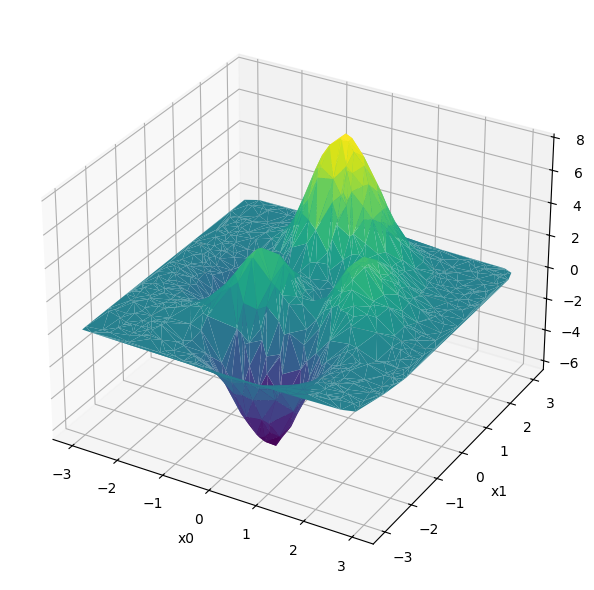

In [59]:
plot_surface(torch.tensor(x_test), torch.tensor(y_test))

In [60]:
scaler = MinMaxScaler(feature_range=(0, 1))

#Training
x_train = scaler.fit_transform(x_train)

#Validation
x_val = scaler.transform(x_val)

#Testing
x_test = scaler.transform(x_test)

In [61]:
dtype = torch.float64
batch_size = 64
shuffle = True

train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(x_train, dtype=dtype), 
        torch.tensor(y_train, dtype=dtype)), 
    batch_size = batch_size,
    shuffle = shuffle)

x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

val_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(x_val, dtype=dtype), 
        torch.tensor(y_val, dtype=dtype)), 
    batch_size = batch_size,
    shuffle = shuffle)

x_val = val_loader.dataset.tensors[0]
y_val = val_loader.dataset.tensors[1]

In [62]:
x_test = torch.tensor(x_test, dtype=dtype)
y_test = torch.tensor(y_test, dtype=dtype)

In [63]:
x_train.dtype

torch.float64

In [64]:
x_train.shape, x_val.shape, x_test.shape

(torch.Size([800, 2]), torch.Size([200, 2]), torch.Size([1000, 2]))

In [65]:
y_train.shape, y_val.shape, y_test.shape

(torch.Size([800]), torch.Size([200]), torch.Size([1000]))

## Model & Training

### ANFIS

In [66]:

model = nft.rule_reduced_ANFIS(
    input_size = 2,
    num_mfs = 3,
    membership_function=nft.GeneralizedBell_MF,
    outputs = 1,
    dtype=dtype
)

In [67]:
model.init_premises(x_train)

In [68]:
model.init_consequents(x_train, y_train, driver="gelsd", ridge_lambda=1.)

In [69]:
print(model.get_rules_structure().to_string())

       premises                           output 1 consequents                    
             x0              x1                             x0        x1          
              a    b    c     a    b    c                   c0        c1        c2
rule 1     0.25  4.0  0.0  0.25  4.0  0.0             1.738038  0.299010 -0.060708
rule 2     0.25  4.0  0.5  0.25  4.0  0.5             4.398952  6.299620 -4.812713
rule 3     0.25  4.0  1.0  0.25  4.0  1.0             1.018425  1.341825 -2.245634


### Hybrid Learning Algorithm

In [70]:
epochs = 500

loss_fn = nn.functional.mse_loss

optimizer = torch.optim.AdamW
params = {'lr': 0.005, 'weight_decay': 0.01}

early_stopping = nft.EarlyStopping(patience=30, delta=0.001)

In [71]:
trainer = nft.Basic_optimizer_training_algorithm(
    epochs=epochs,
    loss_function=loss_fn,
    #driver="gelsd",
    #ridge_lambda=1e-1,
    optimizer=optimizer,
    optimizer_params=params,
    early_stopping=early_stopping
)

In [72]:
"""
trainer(model, train_loader, val_loader, verbose=True)

pred = model.predict(x_test)

mse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)

print("\n ------ Evaluation ------")
print("\n")
print("mse:", mse)
print("rmse:", rmse)
print("mae:", mae)
print("r2 score:", r2)
print("mape:", mape, "\n")

print("Test data")
plot_surface(x_test, y_test)

pred = model.predict(x_test)

print("Model Prediction")
plot_surface(x_test, pred)
"""

'\ntrainer(model, train_loader, val_loader, verbose=True)\n\npred = model.predict(x_test)\n\nmse = mean_squared_error(y_test, pred)\nrmse = root_mean_squared_error(y_test, pred)\nmae = mean_absolute_error(y_test, pred)\nr2 = r2_score(y_test, pred)\nmape = mean_absolute_percentage_error(y_test, pred)\n\nprint("\n ------ Evaluation ------")\nprint("\n")\nprint("mse:", mse)\nprint("rmse:", rmse)\nprint("mae:", mae)\nprint("r2 score:", r2)\nprint("mape:", mape, "\n")\n\nprint("Test data")\nplot_surface(x_test, y_test)\n\npred = model.predict(x_test)\n\nprint("Model Prediction")\nplot_surface(x_test, pred)\n'

### SONFIS

In [73]:
Ngrow = 100
dGrow = 0.8
Nsplit = 140
eSplit = 0.15
Nvanish = 10
lVanish = 3

max_iterations = 100

anfis_trainer = trainer

sonfis_early_stopping = nft.EarlyStopping(patience=15)
last_training_iteration = True

lse_for_new_consequents = True
lse_for_new_consequents_lambda = 1e-1

In [74]:
sonfis = nft.SONFIS(
    Ngrow=Ngrow,
    dGrow=dGrow,
    Nsplit=Nsplit,
    eSplit=eSplit,
    Nvanish=Nvanish,
    lVanish=lVanish,
    max_iterations=max_iterations,
    ANFIStrainer=anfis_trainer,
    early_stopping=sonfis_early_stopping,
    lse_for_new_consequents=lse_for_new_consequents,
    lse_for_new_consequents_lambda=lse_for_new_consequents_lambda,
    last_training_iteration=last_training_iteration
)

In [75]:
%time sonfis(model, train_loader, val_loader, verbose=True)

ITERATION:   0/100



STARTING STATE:
   premises                                                   output 1 consequents                     
         x0                            x1                                       x0         x1          
          a         b         c         a         b         c                   c0         c1        c2
0  0.050263  2.036756  0.295556  0.334645  9.987524  0.306864             0.226213  -2.639531  0.233320
1  0.092276  2.889325  0.510522  0.317589  7.585979  0.549387             0.991239  13.623934 -5.498177
2  0.885134   2.89673  0.493014  0.169738  2.724085  1.084686             0.189336   0.710343 -0.479564

	loss: 2.615854 - validation loss: 2.914925
	 --> ANFIS rules: 3


ITERATION:   1/100
	-> Growing 3 new subnets: [3, 4, 5]

CURRENT STATE:
   premises                                                   output 1 consequents                      
         x0                            x1                                       x0         x1           
         

In [76]:
print(model.get_rules_structure().to_string())

         premises                                                   output 1 consequents                      
               x0                            x1                                       x0         x1           
                a         b         c         a         b         c                   c0         c1         c2
rule 1   0.024627  1.163798  0.201002  0.368777  9.307293  0.314526             0.748412  -2.816591   0.753410
rule 2    0.07898  2.031136  0.492596  0.270771  7.590851  0.580368             2.494931  14.213221  -3.467399
rule 3   1.422563  3.501151  0.541411  0.236486  2.015569  1.161791             0.026399   0.725340  -0.596887
rule 4   0.862166  3.966927  0.573245  0.120906  2.578716  0.014653             0.026510   0.231836  -0.190007
rule 5   0.094798  3.127367  0.568609  0.187897  3.202483  0.327514            13.423623  18.187452 -17.201215
rule 6   0.166437  5.415747  0.535151  0.167411  5.721756  0.533716             1.266793   2.109020   1.482500
r


 ------ Evaluation ------


mse: 0.12471614033965854
rmse: 0.3531517242484575
mae: 0.24652860406673033
r2 score: 0.9685591641366963
mape: 35.89145835031106 

Test data


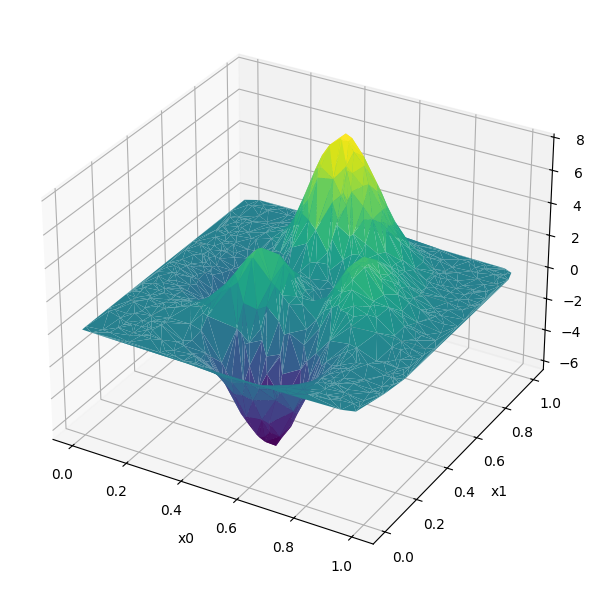

Model Prediction


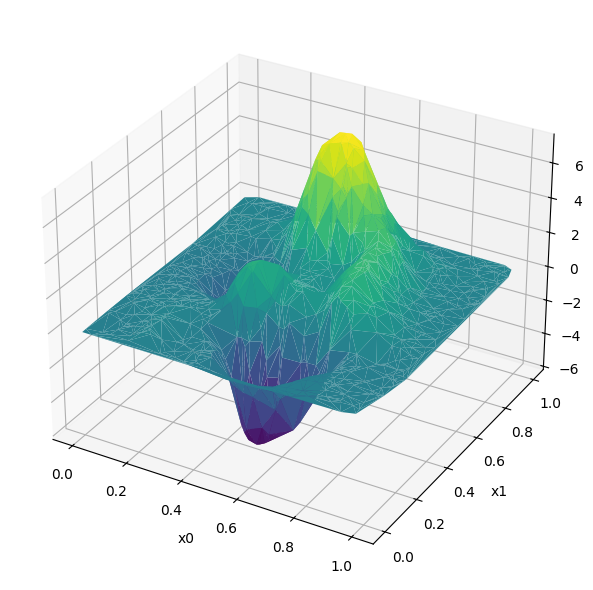

In [77]:
pred = model.predict(x_test)

mse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)

print("\n ------ Evaluation ------")
print("\n")
print("mse:", mse)
print("rmse:", rmse)
print("mae:", mae)
print("r2 score:", r2)
print("mape:", mape, "\n")

print("Test data")
plot_surface(x_test, y_test)

pred = model.predict(x_test)

print("Model Prediction")
plot_surface(x_test, pred)

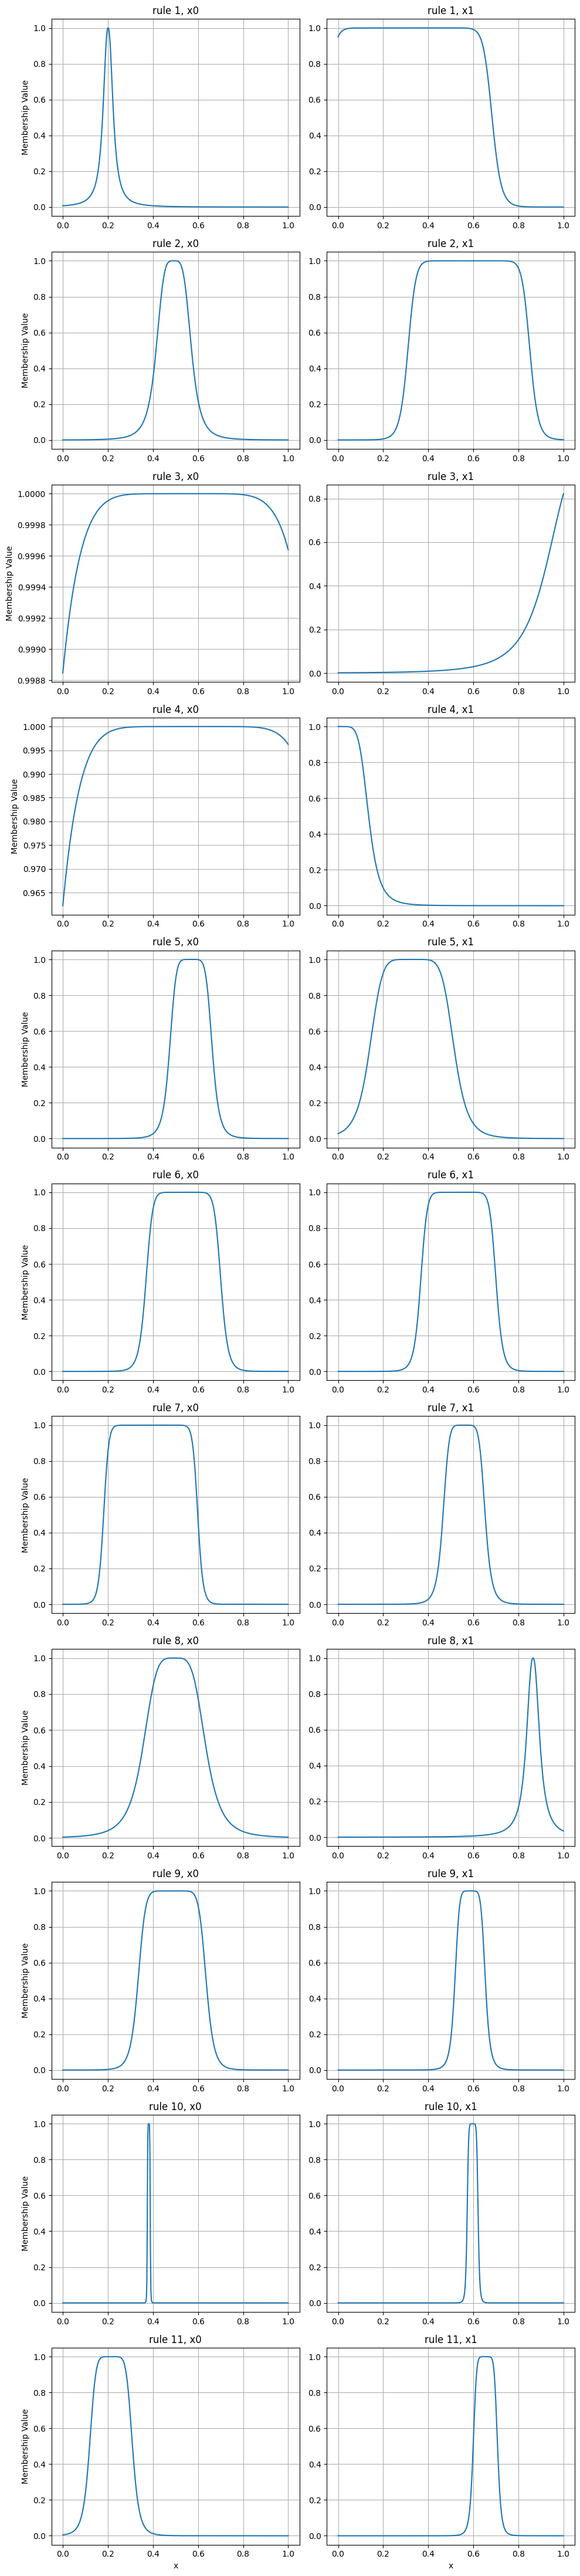

In [78]:
model.plot_premises()